#  Modelado Predictivo de Precios - Airbnb CDMX

En esta fase construiremos modelos para predecir el precio por noche. Compararemos una **Regresión Lineal** básica con un **Random Forest Regressor** para entender si la complejidad de los bosques permite capturar mejor la variabilidad del mercado.

In [17]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración de rutas
sys.path.append(os.path.abspath('../src'))
from visualization import plot_model_results, save_fig

### 1. Preparación de Datos

Cargamos los datos y aplicamos el filtrado de outliers propuesto (Precio < $10,000).

In [ ]:
df = pd.read_csv('../data/processed/listings_clean.csv')

# Filtrado de outliers para el entrenamiento
df = df[df['price'] < 10000].copy()

# Selección de features según lo solicitado
features = ['latitude', 'longitude', 'minimum_nights', 
            'number_of_reviews', 'availability_365',
            'room_type', 'neighbourhood']

# Aplicar One-Hot Encoding (get_dummies)
df_model = pd.get_dummies(df[features + ['price']], 
                          columns=['room_type', 'neighbourhood'], 
                          drop_first=True)

X = df_model.drop('price', axis=1)
y = df_model['price']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de entrenamiento: {X_train.shape}")
print(f"Set de prueba: {X_test.shape}")

Set de entrenamiento: (18667, 23)
Set de prueba: (4667, 23)


### 2. Modelo A: Regresión Lineal

Este modelo asume una relación lineal entre las variables.

--- Regresión Lineal ---
MAE: 639.49
RMSE: 1006.13
R2 Score: 0.17


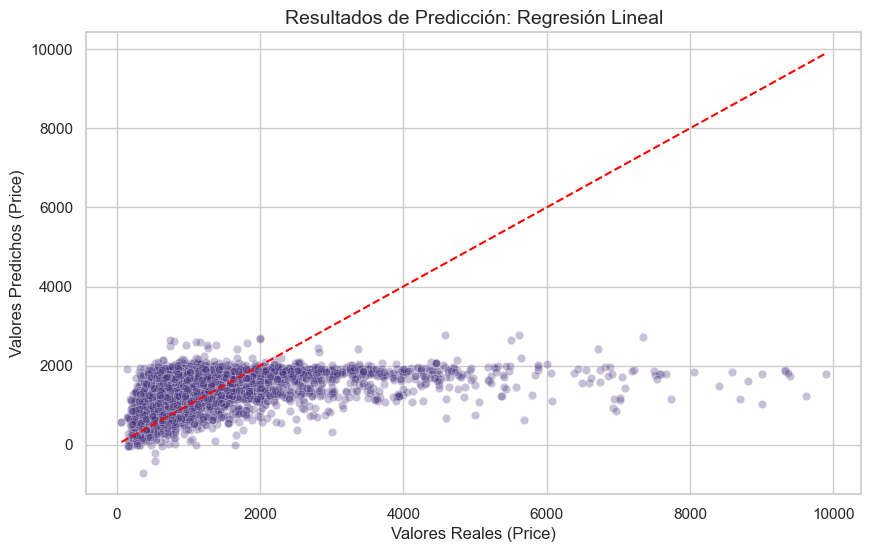

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Métricas
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"--- Regresión Lineal ---")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R2 Score: {r2_lr:.2f}")

plot_model_results(y_test, y_pred_lr, "Regresión Lineal")

### 3. Modelo B: Random Forest Regressor

Un modelo basado en ensamble de árboles que puede capturar relaciones no lineales y geográficas.

--- Random Forest ---
MAE: 533.10
RMSE: 897.07
R2 Score: 0.34


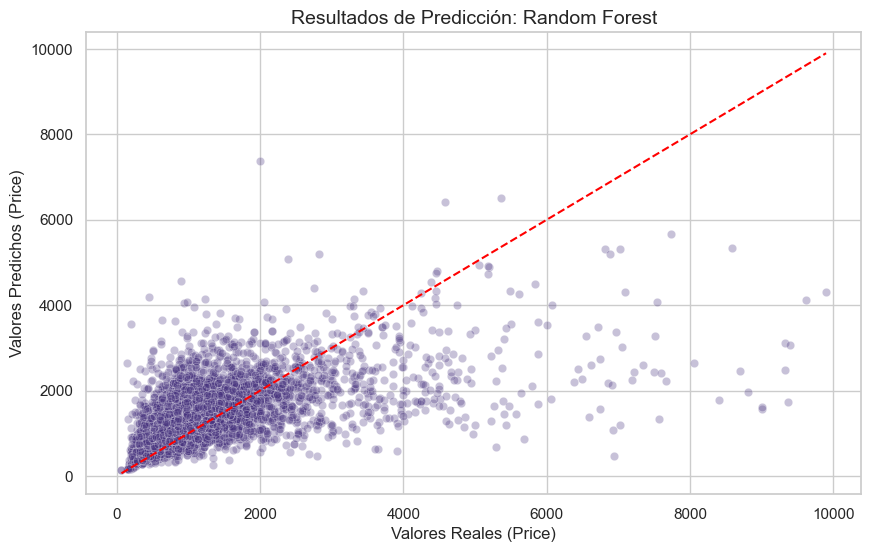

In [20]:
# Entrenamos el modelo RandomForest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Métricas solicitadas
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"--- Random Forest ---")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R2 Score: {r2_rf:.2f}")

plot_model_results(y_test, y_pred_rf, "Random Forest")

### 4. Importancia de Variables

Visualizamos las 15 variables más importantes que determinan el precio según nuestro modelo.

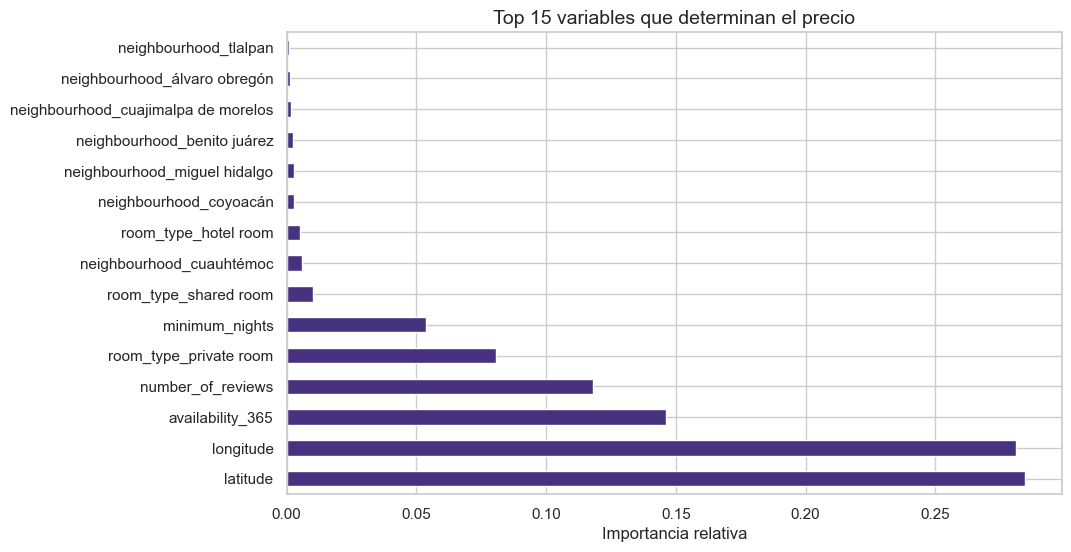

[visualization] Figura guardada en: C:\Users\Acer\Documents\Proyecto1\Airbnb\reports\figures\06_importancia_variables_rf.png


<Figure size 1000x600 with 0 Axes>

In [21]:
# Cálculo y gráfica de importancia de variables
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)[:15]

importances.plot(kind='barh', figsize=(10,6))
plt.title('Top 15 variables que determinan el precio')
plt.xlabel('Importancia relativa')
plt.show()

save_fig("06_importancia_variables_rf")

### 5. Análisis de Relaciones No Lineales (Reseñas vs Precio)

Investigamos por qué el modelo Random Forest considera las reseñas una variable relevante a pesar de su baja correlación lineal.

Mediana de precio por rango de reseñas:
review_bins
0-10      1023.0
11-50     1031.0
51-100    1065.0
100+      1017.5
Name: price, dtype: float64


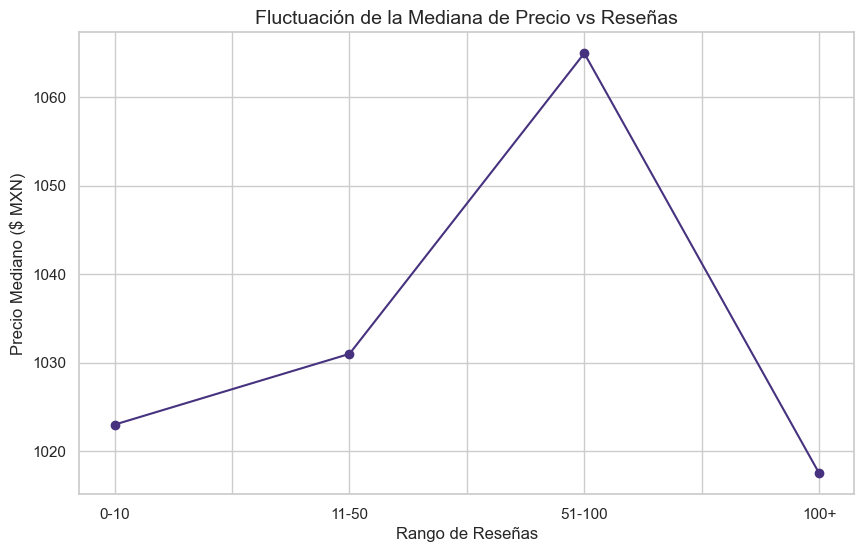

In [22]:
# Agrupación por rangos de reseñas para observar la fluctuación de la mediana del precio
bins = [0, 10, 50, 100, 1000]
labels = ['0-10', '11-50', '51-100', '100+']
df['review_bins'] = pd.cut(df['number_of_reviews'], bins=bins, labels=labels, include_lowest=True)
print("Mediana de precio por rango de reseñas:")
print(df.groupby('review_bins', observed=True)['price'].median())

df.groupby('review_bins', observed=True)['price'].median().plot(kind='line', marker='o')
plt.title('Fluctuación de la Mediana de Precio vs Reseñas')
plt.ylabel('Precio Mediano ($ MXN)')
plt.xlabel('Rango de Reseñas')
plt.show()

##  Insight Final

La relación entre reseñas y precio **no es lineal**: listings en el rango 50-100 reseñas tienen la mediana más alta (**$1,065 MXN**), mientras que listings nuevos (0-10) cobran menos para atraer sus primeras reservas y los muy populares (100+) tienden a ser más accesibles por alta rotación. 

Esto explica por qué el heatmap mostró una correlación cercana a cero pero el modelo **Random Forest** lo identificó como una variable relevante, ya que el modelo pudo capturar esta fluctuación no lineal demostrada anteriormente.

### 6. Comparativa Final de Modelos

In [24]:
metrics = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

display(metrics.sort_values(by='MAE'))

,Modelo,MAE,RMSE,R2 Score
1,Random Forest,533.098244,897.068489,0.342017
0,Regresión Lineal,639.490900,1006.126807,0.172308
